⚠️ Model tidak ditemukan. Melatih model baru sebentar untuk demonstrasi...


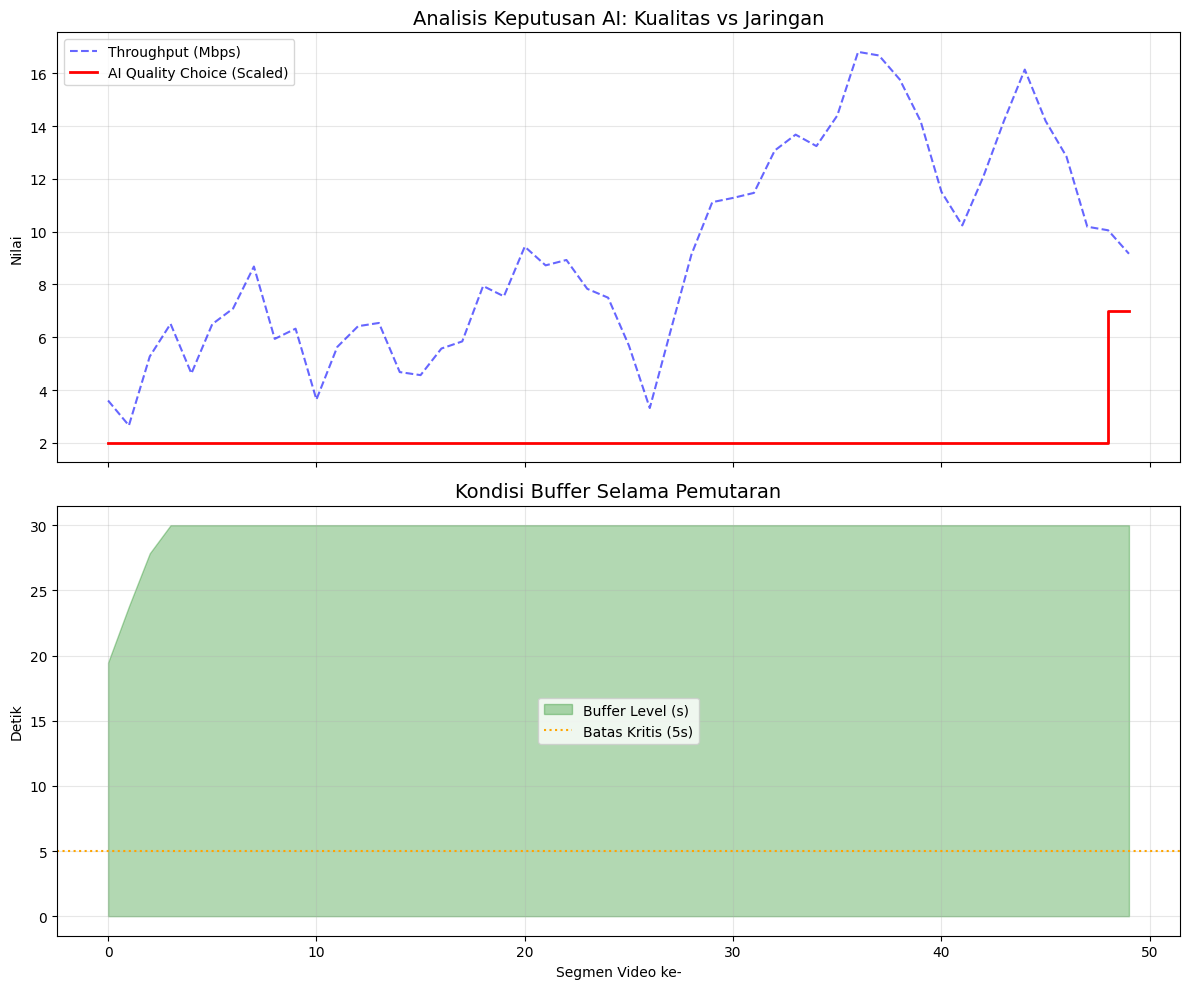


--- Cuplikan Log Keputusan AI ---
   Step  Throughput     Buffer Quality_Action
0     0    3.604511  19.459805              0
1     1    2.657784  23.769972              0
2     2    5.270497  27.839682              0
3     3    6.509277  30.000000              0
4     4    4.628157  30.000000              0
5     5    6.496930  30.000000              0
6     6    7.088686  30.000000              0
7     7    8.679376  30.000000              0
8     8    5.938167  30.000000              0
9     9    6.325632  30.000000              0


In [6]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import pandas as pd

# Kita definisikan ulang Environment agar skrip ini bisa berjalan mandiri
class ShakaNDNEnv(gym.Env):
    def __init__(self):
        super(ShakaNDNEnv, self).__init__()
        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 0, 0]),
            high=np.array([30, 20, 2, 1000, 100]),
            dtype=np.float32
        )
        self.state = None
        self.max_steps = 50 
        self.current_step = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = np.array([15.0, 5.0, 1.0, 50.0, 0.0], dtype=np.float32)
        self.current_step = 0
        return self.state, {}

    def step(self, action):
        buffer, throughput, last_qual, rtt, dropped = self.state
        bitrate_levels = [0.5, 2.5, 8.0]
        chosen_bitrate = bitrate_levels[action]
        
        segment_size = chosen_bitrate * 5
        download_time = (segment_size / (throughput + 0.1)) + (rtt / 1000.0)
        
        new_buffer = buffer - download_time + 5
        if new_buffer < 0: new_buffer = 0
        new_buffer = min(new_buffer, 30.0)

        # Simulasi fluktuasi jaringan yang drastis untuk testing
        new_throughput = np.clip(throughput + np.random.uniform(-3, 3), 0.5, 20.0)
        new_rtt = np.clip(rtt + np.random.uniform(-50, 50), 10, 500)
        
        self.state = np.array([new_buffer, new_throughput, float(action), new_rtt, 0.0], dtype=np.float32)
        self.current_step += 1
        done = self.current_step >= self.max_steps
        return self.state, 0, done, False, {}

def run_evaluation():
    env = ShakaNDNEnv()
    
    # Mencoba memuat model, jika belum ada kita latih sebentar (dummy training)
    try:
        model = PPO.load("ndn_video_brain_shaka")
        print("✅ Model berhasil dimuat.")
    except:
        print("⚠️ Model tidak ditemukan. Melatih model baru sebentar untuk demonstrasi...")
        model = PPO("MlpPolicy", env, verbose=0)
        model.learn(total_timesteps=5000)

    # List untuk menyimpan data hasil testing
    history = []
    obs, _ = env.reset()

    for i in range(50):
        # AI memberikan prediksi tindakan (action) berdasarkan observasi (obs)
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(action)
        
        # Simpan data ke history
        history.append({
            'Step': i,
            'Buffer': obs[0],
            'Throughput': obs[1],
            'Quality_Action': action, # 0=Low, 1=Mid, 2=High
            'RTT': obs[3]
        })
        if done: break

    # Ubah ke Pandas DataFrame agar mudah diolah
    df = pd.DataFrame(history)

    # --- VISUALISASI ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # Grafik 1: Kualitas Video vs Kecepatan Internet
    ax1.plot(df['Step'], df['Throughput'], color='blue', label='Throughput (Mbps)', alpha=0.6, linestyle='--')
    ax1.step(df['Step'], df['Quality_Action'] * 5 + 2, color='red', label='AI Quality Choice (Scaled)', where='post', linewidth=2)
    ax1.set_title("Analisis Keputusan AI: Kualitas vs Jaringan", fontsize=14)
    ax1.set_ylabel("Nilai")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Grafik 2: Kondisi Buffer
    ax2.fill_between(df['Step'], df['Buffer'], color='green', alpha=0.3, label='Buffer Level (s)')
    ax2.axhline(y=5, color='orange', linestyle=':', label='Batas Kritis (5s)')
    ax2.set_title("Kondisi Buffer Selama Pemutaran", fontsize=14)
    ax2.set_ylabel("Detik")
    ax2.set_xlabel("Segmen Video ke-")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Tampilkan Tabel 5 data pertama
    print("\n--- Cuplikan Log Keputusan AI ---")
    print(df[['Step', 'Throughput', 'Buffer', 'Quality_Action']].head(10))

if __name__ == "__main__":
    run_evaluation()

In [5]:
import pandas
import torch
import gymnasium as gym